# Clasificación clásica de pólipos

Esta libreta solo clasifica `AD`, `HP` y `ASS` a partir de la imagen. No usa máscaras ni intenta predecir segmentaciones.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = next((candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "pyproject.toml").exists()), Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.polyp_benchmark_utils import load_benchmark_splits
from src.preprocessing.polyp_classification_benchmark_utils import (
    CLASS_ORDER,
    EXPORT_DIR,
    best_classification_results,
    build_estimator,
    build_feature_table,
    classification_results_frame,
    evaluate_classification_models,
    render_classification_confusion_matrices,
    render_random_classification_examples,
    summarize_predictions,
)

sns.set_theme(style="whitegrid", context="notebook")

## Carga de datos

Se usan los tres cortes para la clasificación: entrenamiento, validación y prueba final.

In [2]:
splits = load_benchmark_splits()
train_df, train_missing = splits["train"]
valid_df, valid_missing = splits["valid"]
test_df, test_missing = splits["test"]

print(f"train: {len(train_df)} filas | faltantes: {len(train_missing)}")
print(f"valid: {len(valid_df)} filas | faltantes: {len(valid_missing)}")
print(f"test:  {len(test_df)} filas | faltantes: {len(test_missing)}")

display(train_df.head(3))

train_features = build_feature_table(train_df)
valid_features = build_feature_table(valid_df)
test_features = build_feature_table(test_df)

feature_cols = [column for column in train_features.columns if column.startswith("f_")]
print(f"Caracteristicas por imagen: {len(feature_cols)}")

train: 788 filas | faltantes: 0
valid: 113 filas | faltantes: 0
test:  225 filas | faltantes: 0


,split,row_index,image_id,cls,Histologia,image_path,mask_path,mask_source
0,train,0,0,HP,1,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,gt
1,train,1,1,AD,1,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,gt
2,train,2,2,HP,1,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,gt


Caracteristicas por imagen: 1100


## Entrenamiento y evaluación

Se comparan todas las familias de modelos, se muestran sus matrices de confusión en validación y luego se reentrena el mejor modelo global para la prueba final.

,model,params,accuracy,balanced_accuracy,macro_f1,weighted_f1,f1_AD,f1_HP,f1_ASS,recall_AD,recall_HP,recall_ASS
2,Logistic Regression,{'C': 1.0},0.592920,0.525016,0.490196,0.608835,0.714286,0.470588,0.285714,0.649351,0.631579,0.294118
1,Logistic Regression,{'C': 0.25},0.566372,0.498814,0.467595,0.585700,0.690647,0.448980,0.263158,0.623377,0.578947,0.294118
4,Logistic Regression,{'C': 8.0},0.575221,0.501079,0.465611,0.589993,0.700000,0.461538,0.235294,0.636364,0.631579,0.235294
3,Logistic Regression,{'C': 3.0},0.575221,0.501079,0.465085,0.589602,0.700000,0.452830,0.242424,0.636364,0.631579,0.235294
7,SVM RBF,"{'C': 3.0, 'gamma': 'scale'}",0.530973,0.369587,0.363036,0.531480,0.684211,0.244898,0.160000,0.675325,0.315789,0.117647
6,SVM RBF,"{'C': 1.5, 'gamma': 'scale'}",0.486726,0.363221,0.356553,0.504239,0.638889,0.230769,0.200000,0.597403,0.315789,0.176471
8,SVM RBF,"{'C': 6.0, 'gamma': 'auto'}",0.584071,0.367067,0.356179,0.558183,0.740741,0.232558,0.095238,0.779221,0.263158,0.058824
17,Gradient Boosting,"{'n_estimators': 150, 'learning_rate': 0.05, '...",0.654867,0.366183,0.344843,0.572202,0.784530,0.000000,0.250000,0.922078,0.000000,0.176471
5,SVM RBF,"{'C': 0.75, 'gamma': 'scale'}",0.451327,0.345905,0.335836,0.472061,0.595745,0.235294,0.176471,0.545455,0.315789,0.176471
18,Gradient Boosting,"{'n_estimators': 250, 'learning_rate': 0.04, '...",0.672566,0.359562,0.333333,0.575221,0.800000,0.000000,0.200000,0.961039,0.000000,0.117647


,model,params,accuracy,balanced_accuracy,macro_f1,weighted_f1,f1_AD,f1_HP,f1_ASS,recall_AD,recall_HP,recall_ASS
0,Logistic Regression,{'C': 1.0},0.592920,0.525016,0.490196,0.608835,0.714286,0.470588,0.285714,0.649351,0.631579,0.294118
1,SVM RBF,"{'C': 3.0, 'gamma': 'scale'}",0.530973,0.369587,0.363036,0.531480,0.684211,0.244898,0.160000,0.675325,0.315789,0.117647
2,Gradient Boosting,"{'n_estimators': 150, 'learning_rate': 0.05, '...",0.654867,0.366183,0.344843,0.572202,0.784530,0.000000,0.250000,0.922078,0.000000,0.176471
3,Random Forest,"{'n_estimators': 400, 'max_depth': None, 'min_...",0.681416,0.348612,0.306541,0.567648,0.808511,0.000000,0.111111,0.987013,0.000000,0.058824
4,Dummy majority,{},0.681416,0.333333,0.270175,0.552306,0.810526,0.000000,0.000000,1.000000,0.000000,0.000000
5,k-NN,"{'n_neighbors': 11, 'weights': 'distance'}",0.557522,0.285942,0.260512,0.501444,0.720930,0.060606,0.000000,0.805195,0.052632,0.000000


Mejor familia de modelos: Logistic Regression | params={'C': 1.0}
Validación: {'accuracy': 0.5929203539823009, 'balanced_accuracy': 0.5250157479259646, 'macro_f1': 0.4901960784313726, 'weighted_f1': 0.6088346843162044, 'f1_AD': 0.7142857142857143, 'f1_HP': 0.47058823529411764, 'f1_ASS': 0.2857142857142857, 'recall_AD': 0.6493506493506493, 'recall_HP': 0.631578947368421, 'recall_ASS': 0.29411764705882354}
Prueba: {'accuracy': 0.38666666666666666, 'balanced_accuracy': 0.2594594594594595, 'macro_f1': 0.26176470588235295, 'weighted_f1': 0.4023529411764706, 'f1_AD': 0.55, 'f1_HP': 0.1411764705882353, 'f1_ASS': 0.09411764705882353, 'recall_AD': 0.5202702702702703, 'recall_HP': 0.15, 'recall_ASS': 0.10810810810810811}
Resultados guardados en C:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\experiments\polyp_classification\classification_model_selection.csv


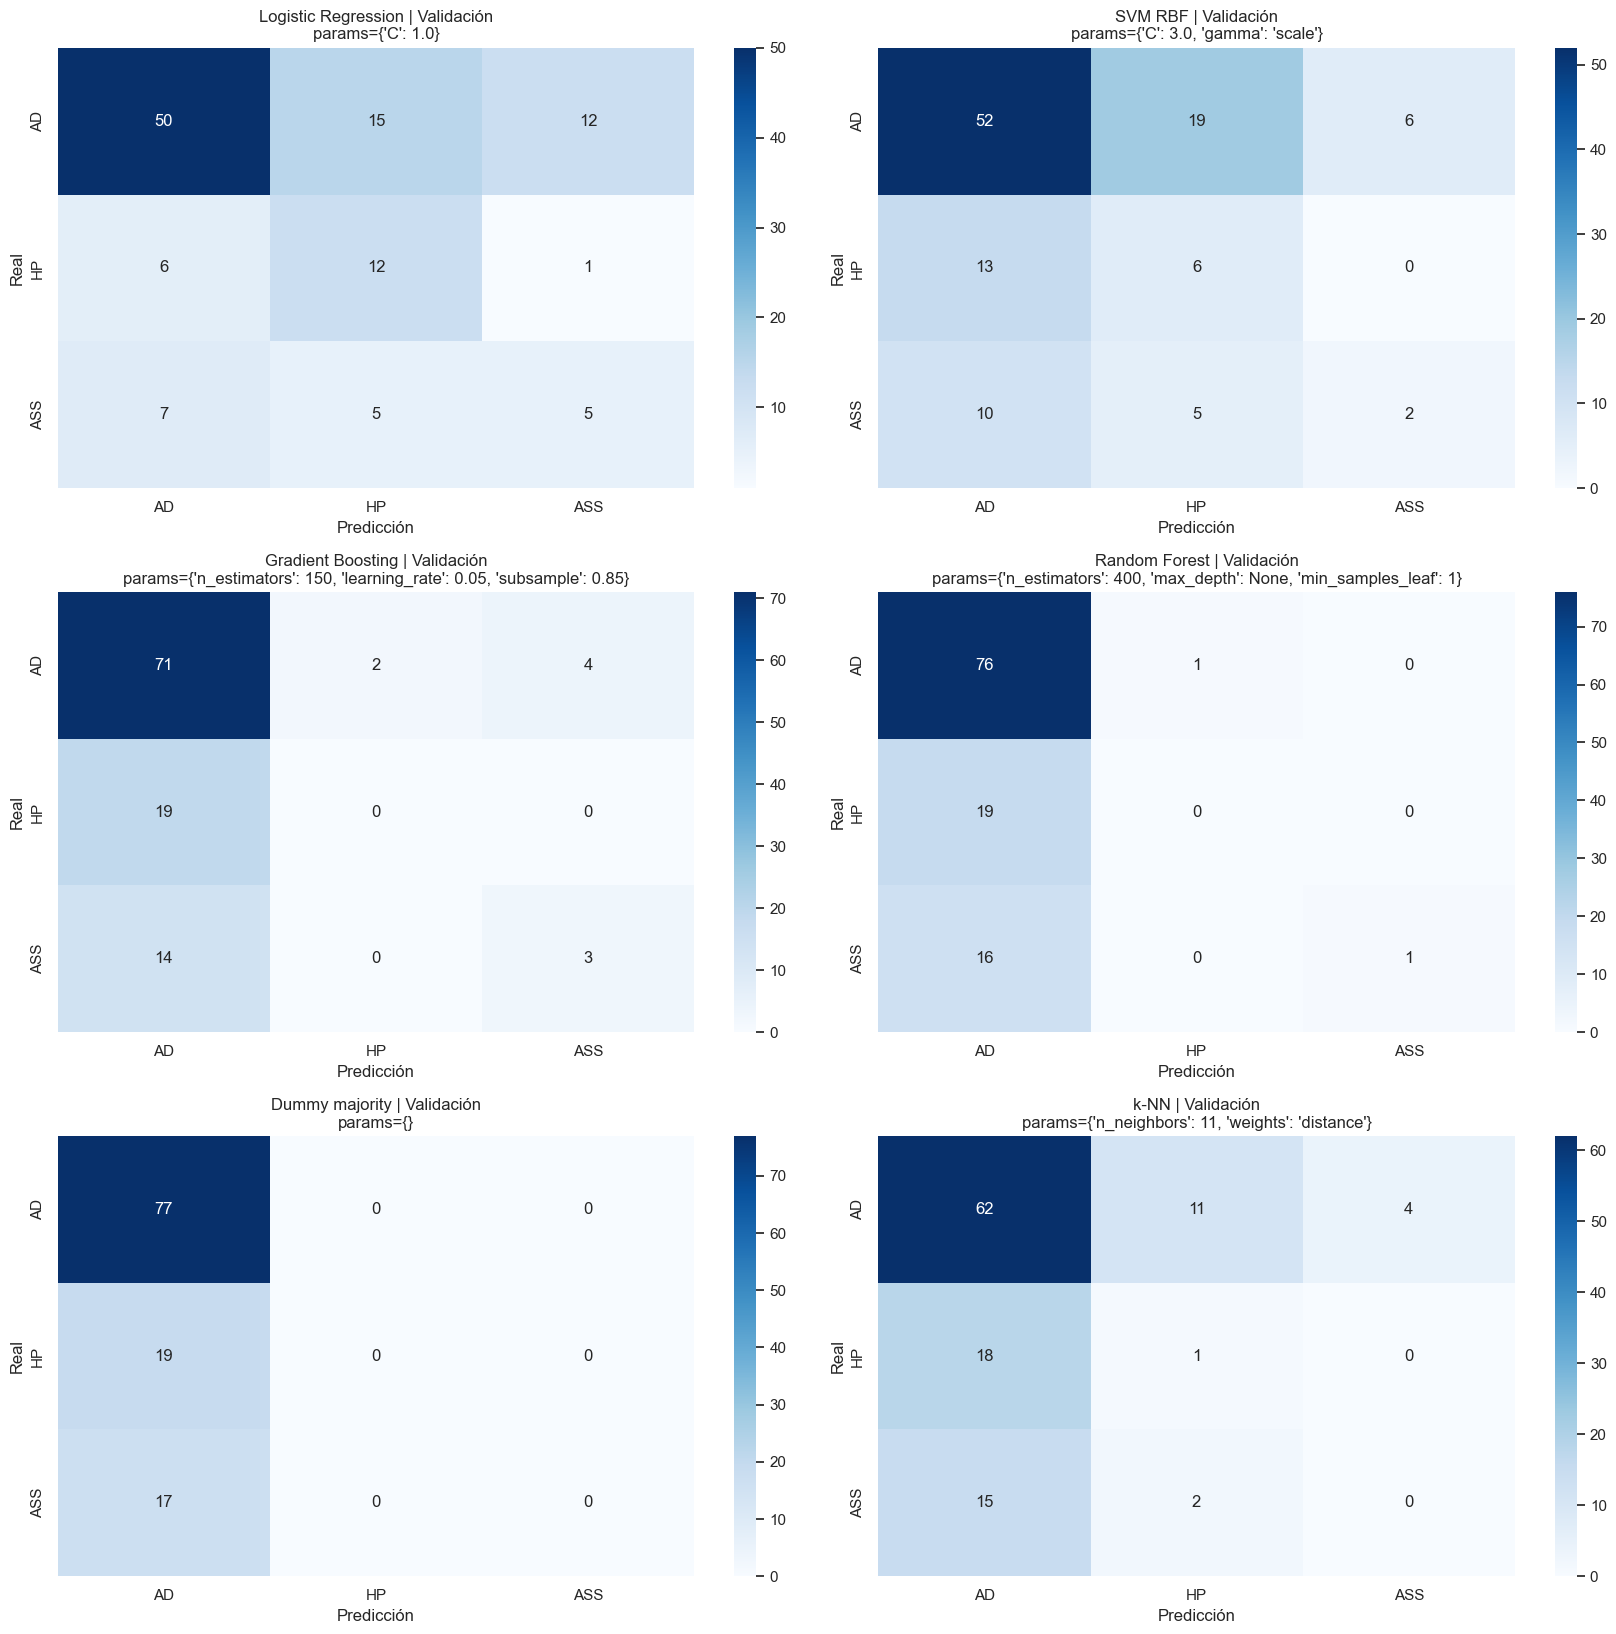

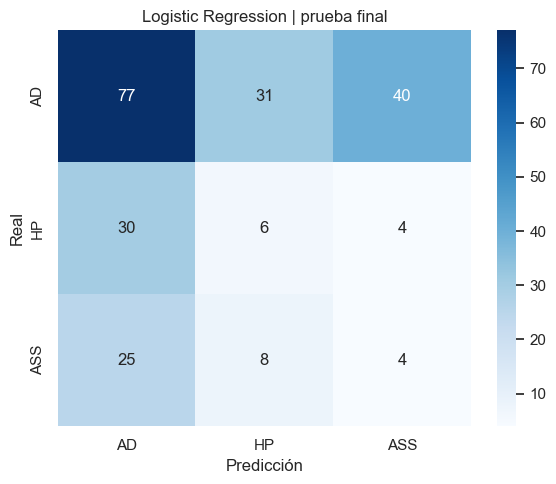

In [3]:
from sklearn.metrics import confusion_matrix

X_train = train_features[feature_cols].to_numpy()
y_train = train_features["cls"].to_numpy()
X_valid = valid_features[feature_cols].to_numpy()
y_valid = valid_features["cls"].to_numpy()
X_test = test_features[feature_cols].to_numpy()
y_test = test_features["cls"].to_numpy()

all_results = evaluate_classification_models(train_features, valid_features, feature_cols)
results_df = classification_results_frame(all_results).sort_values(["macro_f1", "balanced_accuracy", "accuracy"], ascending=False)
display(results_df)

family_best_map = best_classification_results(all_results)
family_best_results = sorted(family_best_map.values(), key=lambda result: result.macro_f1, reverse=True)
family_results_df = classification_results_frame(family_best_results).sort_values(["macro_f1", "balanced_accuracy", "accuracy"], ascending=False)
display(family_results_df)

render_classification_confusion_matrices(valid_features["cls"], family_best_results, title_prefix="Validación")

if not family_best_results:
    raise RuntimeError("No se pudo entrenar ningún modelo")

overall_best = family_best_results[0]
best_model_name = overall_best.model
best_params = dict(overall_best.params)
validation_summary = {
    "accuracy": overall_best.accuracy,
    "balanced_accuracy": overall_best.balanced_accuracy,
    "macro_f1": overall_best.macro_f1,
    "weighted_f1": overall_best.weighted_f1,
    "f1_AD": overall_best.f1_AD,
    "f1_HP": overall_best.f1_HP,
    "f1_ASS": overall_best.f1_ASS,
    "recall_AD": overall_best.recall_AD,
    "recall_HP": overall_best.recall_HP,
    "recall_ASS": overall_best.recall_ASS,
}

best_estimator = build_estimator(best_model_name, best_params)
combined_features = pd.concat([train_features, valid_features], ignore_index=True)
combined_X = combined_features[feature_cols].to_numpy()
combined_y = combined_features["cls"].to_numpy()
best_estimator.fit(combined_X, combined_y)

test_pred = best_estimator.predict(X_test)
test_summary = summarize_predictions(pd.Series(y_test), test_pred)

print(f"Mejor familia de modelos: {best_model_name} | params={best_params}")
print("Validación:", validation_summary)
print("Prueba:", test_summary)

results_path = EXPORT_DIR / "classification_model_selection.csv"
results_df.to_csv(results_path, index=False)
print(f"Resultados guardados en {results_path}")

cm = confusion_matrix(y_test, test_pred, labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title(f"{best_model_name} | prueba final")
plt.tight_layout()

## Ejemplos visuales

Se inspeccionan algunas predicciones del mejor modelo global sobre validación y prueba.

c:\Users\david\Desktop\TFG\TFG_VLM_Medical\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
c:\Users\david\Desktop\TFG\TFG_VLM_Medical\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
c:\Users\david\Desktop\TFG\TFG_VLM_Medical\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
c:\Users\david\Desktop\TFG\TFG_VLM_Medical\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


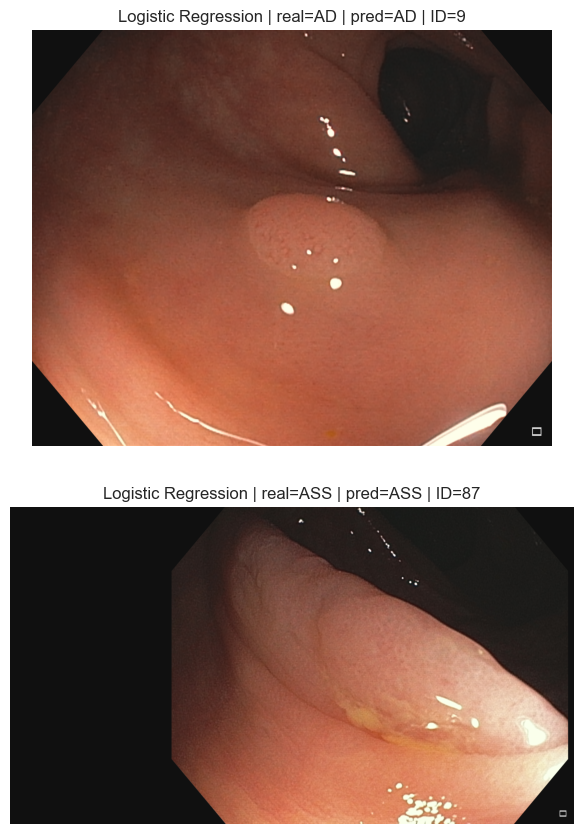

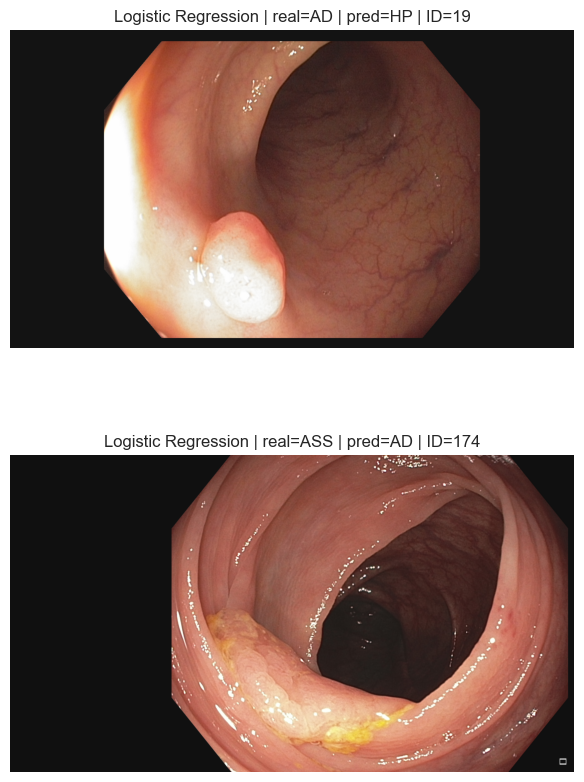

In [ ]:
render_random_classification_examples(
    best_model_name,
    best_estimator,
    valid_df,
    valid_features,
    feature_cols,
    n_samples=2,
)

render_random_classification_examples(
    best_model_name,
    best_estimator,
    test_df,
    test_features,
    feature_cols,
    n_samples=2,
)